# Задача с Agents Week Yandex

Магические руны Элдории
В фэнтезийном мире Элдории маги используют древнюю систему рун для создания заклинаний. Ученые-артефакторы выяснили несколько особенностей этой системы:

В рунах используется всего 3 символа: F (огонь), W (вода) и E (земля).
Все последовательности состоят ровно из 5 символов.
Не все последовательности из 5 символов являются валидными заклинаниями — только те, что следуют скрытым магическим правилам баланса элементов.
Артефакторы собрали примеры 5-символьных последовательностей во время экспедиции в руины древних храмов. Некоторые из них активируют магию (валидные), другие — нет. Помогите артефакторам завершить каталог и определить, какие из неразмеченных последовательностей являются настоящими заклинаниями.

О датасете
Вам предлагаются три файла: train_runes.csv, test_runes.csv и example.csv:

Файл train_runes.csv содержит колонку rune с 5-символьными последовательностями и колонку spell, в которой 1 означает, что последовательность является валидным заклинанием, а 0 — что нет.
Файл test_runes.csv содержит 5-символьные последовательности, среди которых вам нужно найти валидные заклинания.
Файл example.csv содержит пример корректной посылки в контест.
Таким образом, вам нужно предсказать колонку spell для последовательностей из файла test_runes.csv.

Что нужно сделать
От вас требуется загрузить в систему файл answers.csv в формате, аналогичном файлу example.csv, с предсказаниями, являются ли 5-символьные последовательности валидными заклинаниями.

В качестве целевой метрики используется доля правильных ответов (accuracy). Баллы за это задание рассчитываются по формуле:

max(2×accuracy−1,0)

где accuracy — доля правильных ответов для ваших предсказаний. Таким образом, для максимального числа баллов необходимо набрать accuracy = 1.

In [266]:
from collections import defaultdict
from itertools import product
import random

import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import optuna

from IPython.display import display

In [93]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [28]:
train_df = pd.read_csv('./data/train_runes.csv')
test_df = pd.read_csv('./data/test_runes.csv')
example_df = pd.read_csv('./data/example.csv')

In [29]:
print(train_df.shape, test_df.shape)
train_df.head()

(170, 2) (73, 1)


,rune,spell
0,WWWWF,1
1,FWEFW,1
2,FFEFF,0
3,EWFWE,1
4,EEEWF,0


In [30]:
test_df.head()

,rune
0,FWFEF
1,EFEEE
2,EFWFE
3,FEWWF
4,WFEFE


In [31]:
example_df.head()

,rune,spell
0,FWFEF,1
1,EFEEE,0
2,EFWFE,1
3,FEWWF,0
4,WFEFE,1


In [32]:
train, val = train_test_split(train_df, test_size=0.3, random_state=SEED, stratify=train_df['spell'])
train.shape, val.shape

((119, 2), (51, 2))

# Baseline

In [39]:
texts_train = train['rune'].values

def tokenize_text(text):
    return list(text)

def tokenize_corpus(texts, tokenizer=tokenize_text, **tokenizer_kwargs):
    return [tokenizer(text, **tokenizer_kwargs) for text in texts]

tokenized_train = tokenize_corpus(texts_train)
print(tokenized_train[:5])

word_counts = defaultdict(int)
doc_n = 0

for text in tokenized_train:
    doc_n += 1
    unique_tokens = set(text)
    for token in unique_tokens:
        word_counts[token] += 1
        
print("Word counts:\n", word_counts)
print("Число документов:", doc_n)

sorted_words = sorted(word_counts.items(), reverse=False, key=lambda pair: (pair[1], pair[0]))
print(sorted_words)

document_freq = [cnt / doc_n for _, cnt in sorted_words]

print(document_freq)

print(f'{" ".join([word for word, _ in sorted_words])}\n{" ".join(map(str, document_freq))}')

word2id = {token: i for i, (token, _) in enumerate(sorted_words)}
print(word2id)

[['F', 'E', 'W', 'E', 'W'], ['W', 'F', 'F', 'F', 'E'], ['E', 'W', 'W', 'F', 'W'], ['E', 'W', 'E', 'F', 'W'], ['E', 'E', 'E', 'W', 'W']]
Word counts:
 defaultdict(<class 'int'>, {'W': 100, 'E': 106, 'F': 106})
Число документов: 119
[('W', 100), ('E', 106), ('F', 106)]
[0.8403361344537815, 0.8907563025210085, 0.8907563025210085]
W E F
0.8403361344537815 0.8907563025210085 0.8907563025210085
{'W': 0, 'E': 1, 'F': 2}


In [42]:
def vectorize(tokenized_corpus, word2id):
    vectorized_texts = np.zeros(shape=(len(tokenized_corpus), len(word2id)), dtype='float32')
        
    for text_i, text in enumerate(tokenized_corpus):
        for token in text:
            if token in word2id:
                vectorized_texts[text_i, word2id[token]] += 1
                
    tf_vectorized = vectorized_texts / vectorized_texts.sum(axis=1, keepdims=True)
    
    tfidf_vectorized = tf_vectorized / document_freq
    
    ltfidf_vectorized = np.log(tf_vectorized + 1) / document_freq
    
    ltfidf_vectorized_scaled = (ltfidf_vectorized - ltfidf_vectorized.mean(axis=0)) / ltfidf_vectorized.std(axis=0, ddof=1)
    return ltfidf_vectorized_scaled

In [44]:
vectorized_train = vectorize(tokenized_train, word2id)

tokenized_val = tokenize_corpus(val['rune'].values)
vectorized_val = vectorize(tokenized_val, word2id)

In [45]:
model = CatBoostClassifier(verbose=100, random_seed=42)
model.fit(ltfidf_vectorized_scaled, train['spell'], eval_set=(vectorized_val, val['spell']))

Learning rate set to 0.018731
0:	learn: 0.6901263	test: 0.6930481	best: 0.6930481 (0)	total: 61.5ms	remaining: 1m 1s
100:	learn: 0.5964006	test: 0.7891942	best: 0.6930481 (0)	total: 96.2ms	remaining: 856ms
200:	learn: 0.5813034	test: 0.8624070	best: 0.6930481 (0)	total: 120ms	remaining: 478ms
300:	learn: 0.5754834	test: 0.9204534	best: 0.6930481 (0)	total: 137ms	remaining: 319ms
400:	learn: 0.5726282	test: 0.9670989	best: 0.6930481 (0)	total: 152ms	remaining: 228ms
500:	learn: 0.5711207	test: 1.0080075	best: 0.6930481 (0)	total: 168ms	remaining: 168ms
600:	learn: 0.5701940	test: 1.0454484	best: 0.6930481 (0)	total: 184ms	remaining: 122ms
700:	learn: 0.5696704	test: 1.0716227	best: 0.6930481 (0)	total: 200ms	remaining: 85.2ms
800:	learn: 0.5693249	test: 1.0904284	best: 0.6930481 (0)	total: 216ms	remaining: 53.6ms
900:	learn: 0.5690363	test: 1.1067845	best: 0.6930481 (0)	total: 231ms	remaining: 25.4ms
999:	learn: 0.5688337	test: 1.1228097	best: 0.6930481 (0)	total: 247ms	remaining: 0us



In [49]:
print(classification_report(val['spell'], model.predict(vectorized_val)))
print(roc_auc_score(val['spell'].values, model.predict_proba(vectorized_val)[:, 1]))

              precision    recall  f1-score   support

           0       0.50      0.48      0.49        27
           1       0.44      0.46      0.45        24

    accuracy                           0.47        51
   macro avg       0.47      0.47      0.47        51
weighted avg       0.47      0.47      0.47        51

0.5023148148148149


In [50]:
tokenized_test = tokenize_corpus(test_df['rune'].values)
vectorized_test = vectorize(tokenized_test, word2id)

In [53]:
test_df['spell'] = model.predict(vectorized_test)

In [54]:
test_df.head()

,rune,spell
0,FWFEF,0
1,EFEEE,0
2,EFWFE,0
3,FEWWF,1
4,WFEFE,0


In [55]:
test_df.to_csv('./data/submission.csv', index=False)

# Position sensitive baseline

In [111]:
train_df = pd.read_csv('./data/train_runes.csv')
test_df = pd.read_csv('./data/test_runes.csv')
example_df = pd.read_csv('./data/example.csv')

In [ ]:
train, val = train_test_split(train_df, test_size=0.3, random_state=SEED, stratify=train_df['spell'])
train.shape, val.shape

In [68]:
for i in range(5):
    listed_rune_train = train['rune'].apply(list)
    listed_rune_val = val['rune'].apply(list)
    listed_rune_test = test_df['rune'].apply(list)
    
    train[f'rune_{i}'] = listed_rune_train.apply(lambda x: x[i])
    val[f'rune_{i}'] = listed_rune_val.apply(lambda x: x[i])
    test_df[f'rune_{i}'] = listed_rune_test.apply(lambda x: x[i])

In [70]:
encoder = OrdinalEncoder()
encoder.fit(train[[f'rune_{i}' for i in range(5)]])

OrdinalEncoder()

In [71]:
encoded_runes_train = encoder.transform(train[[f'rune_{i}' for i in range(5)]])
encoded_runes_val = encoder.transform(val[[f'rune_{i}' for i in range(5)]])
encoded_runes_test = encoder.transform(test_df[[f'rune_{i}' for i in range(5)]])

In [82]:
model = CatBoostClassifier(n_estimators=50000, verbose=10000, random_seed=42)
model.fit(encoded_runes_train, train['spell'], eval_set=(encoded_runes_val, val['spell']))

Learning rate set to 0.003416
0:	learn: 0.6903331	test: 0.6913657	best: 0.6913657 (0)	total: 846us	remaining: 42.3s
10000:	learn: 0.0036441	test: 0.0323699	best: 0.0323699 (10000)	total: 1.61s	remaining: 6.44s
20000:	learn: 0.0017233	test: 0.0232729	best: 0.0232729 (20000)	total: 3.17s	remaining: 4.76s
30000:	learn: 0.0011882	test: 0.0202282	best: 0.0202282 (30000)	total: 4.69s	remaining: 3.13s
40000:	learn: 0.0011056	test: 0.0197266	best: 0.0197266 (34517)	total: 6.05s	remaining: 1.51s
49999:	learn: 0.0011056	test: 0.0197266	best: 0.0197266 (34517)	total: 7.38s	remaining: 0us

bestTest = 0.0197265724
bestIteration = 34517

Shrink model to first 34518 iterations.


In [83]:
print(classification_report(val['spell'], model.predict(encoded_runes_val)))
print(roc_auc_score(val['spell'].values, model.predict_proba(encoded_runes_val)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        24

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

1.0


In [84]:
test_df.head()

,rune,spell,rune_0,rune_1,rune_2,rune_3,rune_4
0,FWFEF,1,F,W,F,E,F
1,EFEEE,0,E,F,E,E,E
2,EFWFE,0,E,F,W,F,E
3,FEWWF,0,F,E,W,W,F
4,WFEFE,0,W,F,E,F,E


In [86]:
old = test_df['spell']

In [87]:
test_df['spell'] = model.predict(encoded_runes_test)

In [89]:
test_df['spell'][old != test_df['spell']]

Series([], Name: spell, dtype: int64)

In [77]:
test_df[['rune', 'spell']].to_csv('./data/submission.csv', index=False)

# Optuna

In [479]:
train_df = pd.read_csv('./data/train_runes.csv')
test_df = pd.read_csv('./data/test_runes.csv')
example_df = pd.read_csv('./data/example.csv')

In [480]:
train, val = train_test_split(train_df, test_size=0.3, random_state=SEED, stratify=train_df['spell'])
train.shape, val.shape

((119, 2), (51, 2))

In [481]:
for i in range(5):
    listed_rune_train = train['rune'].apply(list)
    listed_rune_val = val['rune'].apply(list)
    listed_rune_test = test_df['rune'].apply(list)
    
    train[f'rune_{i}'] = listed_rune_train.apply(lambda x: x[i])
    val[f'rune_{i}'] = listed_rune_val.apply(lambda x: x[i])
    test_df[f'rune_{i}'] = listed_rune_test.apply(lambda x: x[i])

In [482]:
encoder = OrdinalEncoder()
encoder.fit(train[[f'rune_{i}' for i in range(5)]])

OrdinalEncoder()

In [483]:
encoded_runes_train = encoder.transform(train[[f'rune_{i}' for i in range(5)]])
encoded_runes_val = encoder.transform(val[[f'rune_{i}' for i in range(5)]])
encoded_runes_test = encoder.transform(test_df[[f'rune_{i}' for i in range(5)]])

In [484]:
train.loc[:, [f'rune_{i}' for i in range(5)]] = encoded_runes_train
train.head()

,rune,spell,rune_0,rune_1,rune_2,rune_3,rune_4
83,FEWEW,0,1.0,0.0,2.0,0.0,2.0
30,WFFFE,0,2.0,1.0,1.0,1.0,0.0
133,EWWFW,0,0.0,2.0,2.0,1.0,2.0
112,EWEFW,0,0.0,2.0,0.0,1.0,2.0
70,EEEWW,0,0.0,0.0,0.0,2.0,2.0


In [485]:
val.loc[:, [f'rune_{i}' for i in range(5)]] = encoded_runes_val
val.head()

,rune,spell,rune_0,rune_1,rune_2,rune_3,rune_4
49,WFFFW,1,2.0,1.0,1.0,1.0,2.0
15,WEFFW,1,2.0,0.0,1.0,1.0,2.0
109,EFFFE,0,0.0,1.0,1.0,1.0,0.0
69,EEWWW,0,0.0,0.0,2.0,2.0,2.0
121,FEEEW,1,1.0,0.0,0.0,0.0,2.0


In [486]:
N_TRIALS = 100
P_WARMUP = 20

kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)

X = train[[f'rune_{i}' for i in range(5)]].reset_index(drop=True)
y = train['spell'].reset_index(drop=True)

def objective(trial):
    params = {
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'iterations': trial.suggest_int('iterations', 100, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5),
        'rsm': trial.suggest_float('rsm', 0.4, 1.0),
#         'bagging_temperature': trial.suggest_float('bagging_temperature', 0., 1.0),  # for Bayessian bootstrap
        'subsample': trial.suggest_float('subsample', 0.2, 1.0),  # for Bernoulli bootstrap
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 250),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced', None]),
        'bootstrap_type': "Bernoulli",
        'random_state': SEED,
        'verbose': False
    }
    metrics = []

    for (train_ix, val_ix) in kfold.split(X, y):
        x_train, y_train = X.loc[train_ix, :], y.loc[train_ix]
        x_val, y_val = X.loc[val_ix, :], y.loc[val_ix]
        
        model = CatBoostClassifier(**params)
        model.fit(x_train, y_train, eval_set=(x_val, y_val), early_stopping_rounds=30)
        
        preds = model.predict(x_val)
        metric = accuracy_score(y_val, preds)
        metrics.append(metric)
    
    return np.mean(metrics)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(n_startup_trials=int(N_TRIALS*(P_WARMUP/100)), multivariate=True)
)
study.optimize(objective, n_trials=N_TRIALS)

/Users/romansafronenkov/Documents/Projects/uplift/venv/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-04-06 15:05:01,158] A new study created in memory with name: no-name-aac1b73b-1d48-47e7-ac57-8e4082216e64
[I 2026-04-06 15:05:01,256] Trial 0 finished with value: 0.9663793103448276 and parameters: {'l2_leaf_reg': 0.00014853564191059205, 'max_depth': 4, 'iterations': 179, 'learning_rate': 0.3067656318444278, 'rsm': 0.5400049235502361, 'subsample': 0.37391962343261886, 'min_data_in_leaf': 110, 'auto_class_weights': None}. Best is trial 0 with value: 0.9663793103448276.
[I 2026-04-06 15:05:01,325] Trial 1 finished with value: 0.9658045977011495 and parameters: {'l2_leaf_reg': 4.9660437100378335e-06, 'max_depth': 4, 'iterations': 763, 'learning_rate': 0.06570105118649719, 'rsm': 0.7299877308472205, 'subsample': 0.8723288280545411, 'min_data_

In [487]:
best_params = study.best_params
best_params['random_state'] = SEED
best_params['bootstrap_type'] = 'Bernoulli'
best_params['verbose'] = False
best_params

{'l2_leaf_reg': 1.2653958393075711e-07,
 'max_depth': 2,
 'iterations': 253,
 'learning_rate': 0.41344805704936743,
 'rsm': 0.5175406195975657,
 'subsample': 0.5990132949528795,
 'min_data_in_leaf': 71,
 'auto_class_weights': None,
 'random_state': 42,
 'bootstrap_type': 'Bernoulli',
 'verbose': False}

In [488]:
model = CatBoostClassifier(**best_params)
model.fit(X, y, eval_set=(val[[f'rune_{i}' for i in range(5)]], val['spell']))

In [489]:
print(classification_report(val['spell'], model.predict(val[[f'rune_{i}' for i in range(5)]])))
print(roc_auc_score(val['spell'].values, model.predict_proba(val[[f'rune_{i}' for i in range(5)]])[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        24

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

1.0


In [490]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,rune_0,31.411887
1,rune_3,28.725649
2,rune_1,23.041235
3,rune_2,12.846217
4,rune_4,3.975012


(array([39.,  0.,  0.,  1.,  0.,  2.,  0.,  0.,  0., 31.]),
 array([4.08581796e-22, 9.99999999e-02, 2.00000000e-01, 3.00000000e-01,
        4.00000000e-01, 5.00000000e-01, 6.00000000e-01, 6.99999999e-01,
        7.99999999e-01, 8.99999999e-01, 9.99999999e-01]),
 <BarContainer object of 10 artists>)

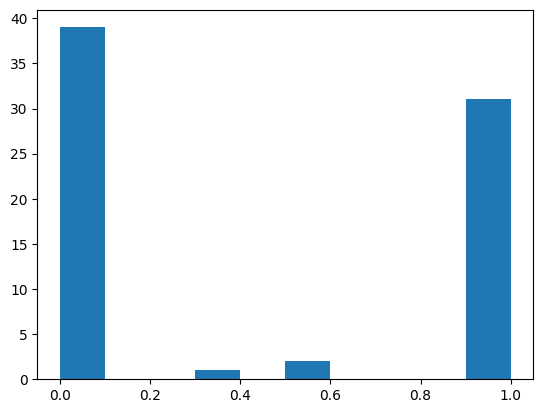

In [494]:
plt.hist(model.predict_proba(encoded_runes_test)[:, 1])

In [496]:
test_df['score'] = model.predict_proba(encoded_runes_test)[:, 1]

In [499]:
test_df['spell'] = model.predict(encoded_runes_test)

In [501]:
test_df[(test_df['score'] > 0.2) & (test_df['score'] < 0.8)]

,rune,rune_0,rune_1,rune_2,rune_3,rune_4,score,spell
42,WFWFW,W,F,W,F,W,0.369140,0
48,FFWFW,F,F,W,F,W,0.536708,1
71,EWWWW,E,W,W,W,W,0.526141,1


In [504]:
test_df.loc[42, 'spell'] = 1 # это дает 100 баллов

In [505]:
test_df[['rune', 'spell']].to_csv('./data/submission.csv', index=False)

# Check combs

In [225]:
all_combs = np.array([''.join(el) for el in list(product(['F', 'W', 'E'], repeat=5))])

In [226]:
all_combs = pd.DataFrame({'rune': all_combs})
all_combs

,rune
0,FFFFF
1,FFFFW
2,FFFFE
3,FFFWF
4,FFFWW
...,...
238,EEEWW
239,EEEWE
240,EEEEF
241,EEEEW


In [227]:
train_df['is_train'] = 1

In [228]:
test_df['is_train'] = 0
test_df['spell'] = np.nan

In [229]:
all_data = pd.concat([train_df, test_df], ignore_index=True, axis=0)

In [230]:
all_combs = all_combs.merge(all_data, on='rune', how='left')

In [231]:
import seaborn as sns

<Axes: ylabel='is_train'>

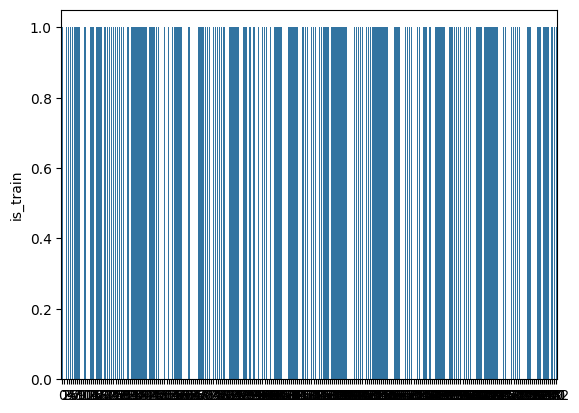

In [232]:
sns.barplot(all_combs['is_train'])

In [241]:
all_combs[['spell', 'is_train']]

,spell,is_train
0,0.0,1
1,NaN,0
2,0.0,1
3,1.0,1
4,1.0,1
...,...,...
238,0.0,1
239,NaN,0
240,0.0,1
241,0.0,1


In [242]:
all_combs

,rune,spell,is_train
0,FFFFF,0.0,1
1,FFFFW,NaN,0
2,FFFFE,0.0,1
3,FFFWF,1.0,1
4,FFFWW,1.0,1
...,...,...,...
238,EEEWW,0.0,1
239,EEEWE,NaN,0
240,EEEEF,0.0,1
241,EEEEW,0.0,1


<Axes: >

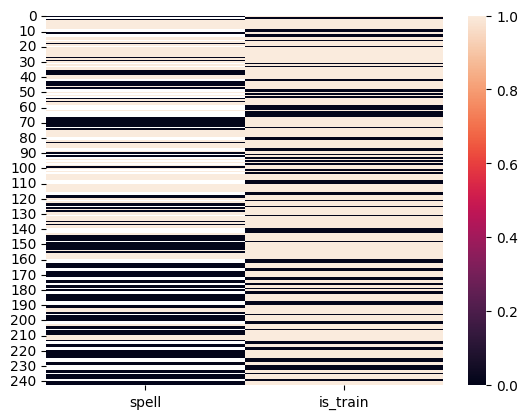

In [240]:
sns.heatmap(data=all_combs[['spell', 'is_train']])

In [244]:
model.predict(encoded_runes_test)

array([1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0])

In [246]:
for i in range(5):
    listed_rune_all = all_combs['rune'].apply(list)
    
    all_combs[f'rune_{i}'] = listed_rune_all.apply(lambda x: x[i])

In [247]:
all_combs

,rune,spell,is_train,rune_0,rune_1,rune_2,rune_3,rune_4
0,FFFFF,0.0,1,F,F,F,F,F
1,FFFFW,NaN,0,F,F,F,F,W
2,FFFFE,0.0,1,F,F,F,F,E
3,FFFWF,1.0,1,F,F,F,W,F
4,FFFWW,1.0,1,F,F,F,W,W
...,...,...,...,...,...,...,...,...
238,EEEWW,0.0,1,E,E,E,W,W
239,EEEWE,NaN,0,E,E,E,W,E
240,EEEEF,0.0,1,E,E,E,E,F
241,EEEEW,0.0,1,E,E,E,E,W


In [249]:
train_check, val_check = train_test_split(all_combs, test_size=0.3, random_state=SEED, stratify=all_combs['is_train'])
train_check.shape, val_check.shape

((170, 8), (73, 8))

In [250]:
encoder_check = OrdinalEncoder()
encoder_check.fit(train_check[[f'rune_{i}' for i in range(5)]])

OrdinalEncoder()

In [251]:
encoded_runes_train_check = encoder.transform(train_check[[f'rune_{i}' for i in range(5)]])
encoded_runes_val_check = encoder.transform(val_check[[f'rune_{i}' for i in range(5)]])

In [258]:
model2 = CatBoostClassifier(n_estimators=1000, verbose=100, random_state=SEED)
model2.fit(encoded_runes_train_check, train_check['is_train'], eval_set=(encoded_runes_val_check, val_check['is_train']))

Learning rate set to 0.020456
0:	learn: 0.6849325	test: 0.6895234	best: 0.6895234 (0)	total: 734us	remaining: 734ms
100:	learn: 0.3989017	test: 0.6093730	best: 0.6029462 (66)	total: 34.3ms	remaining: 305ms
200:	learn: 0.2819918	test: 0.6516710	best: 0.6029462 (66)	total: 59.2ms	remaining: 235ms
300:	learn: 0.2007940	test: 0.7086679	best: 0.6029462 (66)	total: 77ms	remaining: 179ms
400:	learn: 0.1472250	test: 0.7731387	best: 0.6029462 (66)	total: 92.5ms	remaining: 138ms
500:	learn: 0.1144450	test: 0.8366568	best: 0.6029462 (66)	total: 108ms	remaining: 108ms
600:	learn: 0.0923551	test: 0.8984695	best: 0.6029462 (66)	total: 124ms	remaining: 82.3ms
700:	learn: 0.0771428	test: 0.9552141	best: 0.6029462 (66)	total: 139ms	remaining: 59.5ms
800:	learn: 0.0650057	test: 1.0035948	best: 0.6029462 (66)	total: 155ms	remaining: 38.6ms
900:	learn: 0.0563771	test: 1.0501666	best: 0.6029462 (66)	total: 171ms	remaining: 18.8ms
999:	learn: 0.0496117	test: 1.0898912	best: 0.6029462 (66)	total: 187ms	remai

In [259]:
print(classification_report(val_check['is_train'], model2.predict(encoded_runes_val_check)))
print(roc_auc_score(val_check['is_train'].values, model2.predict_proba(encoded_runes_val_check)[:, 1]))

              precision    recall  f1-score   support

           0       0.50      0.09      0.15        22
           1       0.71      0.96      0.82        51

    accuracy                           0.70        73
   macro avg       0.61      0.53      0.49        73
weighted avg       0.65      0.70      0.62        73

0.5846702317290552


In [260]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,rune_0,34.071832
1,rune_3,27.065261
2,rune_1,23.450671
3,rune_2,10.614448
4,rune_4,4.797788


In [268]:
for i in range(5):
    display(all_combs.groupby('is_train')[f'rune_{i}'].value_counts(normalize=True))

is_train  rune_0
0         E         0.369863
          F         0.315068
          W         0.315068
1         F         0.341176
          W         0.341176
          E         0.317647
Name: proportion, dtype: float64

is_train  rune_1
0         F         0.356164
          E         0.342466
          W         0.301370
1         W         0.347059
          E         0.329412
          F         0.323529
Name: proportion, dtype: float64

is_train  rune_2
0         W         0.424658
          F         0.315068
          E         0.260274
1         E         0.364706
          F         0.341176
          W         0.294118
Name: proportion, dtype: float64

is_train  rune_3
0         F         0.356164
          E         0.342466
          W         0.301370
1         W         0.347059
          E         0.329412
          F         0.323529
Name: proportion, dtype: float64

is_train  rune_4
0         W         0.369863
          E         0.342466
          F         0.287671
1         F         0.352941
          E         0.329412
          W         0.317647
Name: proportion, dtype: float64

In [459]:
all_combs

,rune,spell,is_train,rune_0,rune_1,rune_2,rune_3,rune_4
0,FFFFF,0.0,1,F,F,F,F,F
1,FFFFW,NaN,0,F,F,F,F,W
2,FFFFE,0.0,1,F,F,F,F,E
3,FFFWF,1.0,1,F,F,F,W,F
4,FFFWW,1.0,1,F,F,F,W,W
...,...,...,...,...,...,...,...,...
238,EEEWW,0.0,1,E,E,E,W,W
239,EEEWE,NaN,0,E,E,E,W,E
240,EEEEF,0.0,1,E,E,E,E,F
241,EEEEW,0.0,1,E,E,E,E,W


# NN

In [506]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [507]:
device ='mps' if torch.backends.mps.is_available() else 'cpu'
device

'mps'

In [508]:
train_df = pd.read_csv('./data/train_runes.csv')
test_df = pd.read_csv('./data/test_runes.csv')
example_df = pd.read_csv('./data/example.csv')

train, val = train_test_split(train_df, test_size=0.3, random_state=SEED, stratify=train_df['spell'])
train.shape, val.shape

((119, 2), (51, 2))

In [509]:
BOS, EOS = '_BOS_', '_EOS_'
generated_train = train['rune'].tolist()
generated_val = val['rune'].tolist()
generated_test = test_df['rune']

train_lines = [[BOS] + list(line) + [EOS] for line in generated_train]
val_lines = [[BOS] + list(line) + [EOS] for line in generated_val]
test_lines = [[BOS] + list(line) + [EOS] for line in generated_test]

train_lines[:3]

[['_BOS_', 'F', 'E', 'W', 'E', 'W', '_EOS_'],
 ['_BOS_', 'W', 'F', 'F', 'F', 'E', '_EOS_'],
 ['_BOS_', 'E', 'W', 'W', 'F', 'W', '_EOS_']]

In [510]:
tokens = []
for text in train_lines:
    tokens.extend(text)
tokens = list(set(tokens))

In [511]:
tokens = sorted(tokens)
n_tokens = len(tokens)
print('n_tokens =', n_tokens)
token_to_id = {token: id for id, token in enumerate(tokens)}
token_to_id

n_tokens = 5


{'E': 0, 'F': 1, 'W': 2, '_BOS_': 3, '_EOS_': 4}

In [512]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

dummy_lines = [
    'EF',
    'EFW',
    'FWWE',
]
print(to_matrix(dummy_lines))

[[0 1 4 4]
 [0 1 2 4]
 [1 2 2 0]]


In [513]:
class RunesDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        x_i = self.x[i]
        y_i = self.y[i]

        return torch.as_tensor(x_i, dtype=torch.int64), torch.as_tensor(y_i, dtype=torch.float32)

In [514]:
def compute_loss(model, batch_x, batch_y):
    """
    bceloss
    """
    logits = model(batch_x)
    loss = F.binary_cross_entropy_with_logits(logits, batch_y)
    return loss 

In [515]:
def score_lines(model, dataloader):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            dev_loss_num += compute_loss(model, batch_x, batch_y).item() * len(batch_x)
            dev_loss_len += len(batch_x)
    return dev_loss_num / dev_loss_len

In [516]:
class RuneClassifier(nn.Module):
    def __init__(self, inp_voc, hid_size, EOS=EOS):
        super().__init__()
        n_tokens = len(inp_voc)
        self.inp_voc = inp_voc
        self.eos = inp_voc[EOS]

        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=hid_size, device=device)
        self.layernorm = nn.LayerNorm(hid_size)
        self.rnn = nn.LSTM(input_size=hid_size, hidden_size=hid_size, num_layers=1, batch_first=True, device=device)

        self.classifier = nn.Linear(hid_size, 1)

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and 'layernorm' not in name:
                nn.init.xavier_uniform_(param)

    def __call__(self, input_ix):
        input_ix = input_ix.to(device)
        x = self.emb(input_ix)
        x = self.layernorm(x)

        output, _ = self.rnn(x)
        last_state = output[:, -2, :]

        out = self.classifier(last_state)

        return out

In [535]:
train_dataset = RunesDataset(x=to_matrix(train_lines), y=train['spell'].values.reshape(-1, 1))
val_dataset = RunesDataset(x=to_matrix(val_lines), y=val['spell'].values.reshape(-1, 1))

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

score_val_every = 200
train_history, val_history = [], []

model = RuneClassifier(inp_voc=token_to_id, hid_size=64)
opt = torch.optim.Adam(model.parameters(), lr=1e-5)

model.to(device)

# score untrained model
val_history.append((0, score_lines(model, val_dataloader)))

In [536]:
model

RuneClassifier(
  (emb): Embedding(5, 64)
  (layernorm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (rnn): LSTM(64, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

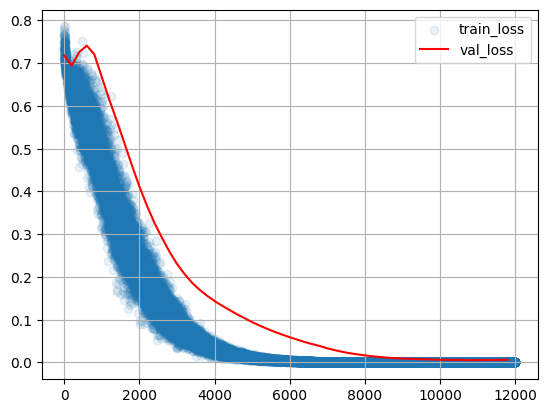

100%|████████████████████████████████████| 12000/12000 [01:46<00:00, 113.08it/s]

Scoring val...
#11999 Val loss: 0.007


In [537]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import trange

best_val_loss = float('inf')

for i in trange(len(train_history), 12000):
    model.train()

    for batch_x, batch_y in train_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        loss_i = compute_loss(model, batch_x, batch_y)
        
        opt.zero_grad()
        loss_i.backward()
        opt.step()
            
        train_history.append((i, loss_i.item()))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(val_history):
            plt.plot(*zip(*val_history), color='red', label='val_loss')
        plt.legend(); plt.grid(); plt.show()
    
    if (i + 1) % score_val_every == 0:
        print("Scoring val...")
        model.eval()
        val_history.append((i, score_lines(model, val_dataloader)))
        print('#%i Val loss: %.3f' % val_history[-1])
        if val_history[-1][1] < best_val_loss:
            best_val_loss = val_history[-1][1]
            torch.save(model.state_dict(), './runes_clf.pth')

In [538]:
model.load_state_dict(torch.load('./runes_clf.pth'))

device = 'cpu'

model.to(device)
model.eval()

RuneClassifier(
  (emb): Embedding(5, 64)
  (layernorm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (rnn): LSTM(64, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

In [539]:
val_preds = F.sigmoid(model(torch.as_tensor(to_matrix(val_lines), dtype=torch.int64))).cpu().detach().numpy().ravel()

In [540]:
print(classification_report(val['spell'], (val_preds>0.5).astype(int)))
print(roc_auc_score(val['spell'].values, val_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        24

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

1.0


In [541]:
from sklearn.metrics import confusion_matrix

In [542]:
print(confusion_matrix(val['spell'], (val_preds>0.5).astype(int)))

[[27  0]
 [ 0 24]]


In [543]:
test_preds = F.sigmoid(model(torch.as_tensor(to_matrix(test_lines), dtype=torch.int64))).cpu().detach().numpy().ravel()

In [544]:
test_df['spell'] = (test_preds > 0.5).astype(int)

In [545]:
test_df[['rune', 'spell']].to_csv('./data/submission_nn.csv', index=False)

(array([39.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., 33.]),
 array([1.68947789e-08, 9.99999791e-02, 1.99999943e-01, 2.99999893e-01,
        3.99999857e-01, 4.99999821e-01, 5.99999785e-01, 6.99999750e-01,
        7.99999714e-01, 8.99999678e-01, 9.99999642e-01]),
 <BarContainer object of 10 artists>)

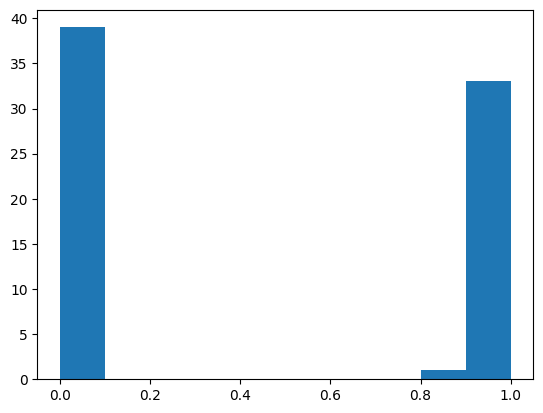

In [546]:
plt.hist(test_preds)

In [547]:
test_df['score'] = test_preds

In [549]:
test_df[(test_df['score'] > 0.3) & (test_df['score'] < 0.9)]

,rune,spell,score
51,FFFFW,1,0.849828


In [550]:
test_df[['rune', 'spell']].to_csv('./data/submission_nn.csv', index=False) # 100 баллов